In [1]:
import numpy
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression #TODO: add yml
import cv2 #TODO: add yml
import os
import random
from tqdm import tqdm
from segment_anything import SamAutomaticMaskGenerator, sam_model_registry, SamPredictor
import argparse
import time
from glob import glob
from utils import NpzDataset
import json

In [2]:
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# training pool
training_pool_path = 'datasets/RAINE_organ_51/MRI_LeftKidney/SAM_sampling/random_100_2024pool.json'
with open(training_pool_path, 'r') as f:
    training_pool = json.load(f)


In [16]:
# get the image embeddings
train_embeddings = []
train_gts = []
print('Start training...')
t1 = time.time()
i = 0 
for fname in tqdm(training_pool):
    # read data
    name = fname.split('/')[-1].split('.')[0]
    embeddings = np.load(fname)['img_embeddings']
    gts = np.load(fname)['gts']
    for emb, gt in zip(embeddings, gts):    # (256, 64, 64) (256, 256)
        emb = emb.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
        # print(emb.shape, gt.shape)
        train_embeddings.append(emb)

        gt = cv2.resize(gt, dsize=(64, 64), interpolation=cv2.INTER_NEAREST)
        train_gts.append(gt.flatten())
    print(f'Add sample {name} with num slices {gts.shape[0]}')
    # break

    # image = cv2.imread(os.path.join(data_path, 'images', fname))
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # mask = cv2.imread(os.path.join(data_path, 'masks', fname))
    # mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    # _, mask = cv2.threshold(mask, 128, 1, cv2.THRESH_BINARY) # threshold the mask to 0 and 1
    # downsampled_mask = cv2.resize(mask, dsize=(64, 64), interpolation=cv2.INTER_NEAREST)
        
    # img_emb = get_embedding(image, predictor)
    # img_emb = img_emb.cpu().numpy().transpose((2, 3, 1, 0)).reshape((64, 64, 256)).reshape(-1, 256)
    # image_embeddings.append(img_emb)

    # labels.append(downsampled_mask.flatten())

# t2 = time.time()
# print("Time used: {}m {}s".format((t2 - t1) // 60, (t2 - t1) % 60))
# image_embeddings_cat = np.concatenate(image_embeddings)
# labels = np.concatenate(labels)

# # Create a linear regression model and fit it to the training data
# model = LogisticRegression(max_iter=1000) 
# model.fit(image_embeddings_cat, labels)

Start training...


  2%|▎         | 1/40 [00:00<00:24,  1.58it/s]

Add sample sub-52220 with num slices 35


  5%|▌         | 2/40 [00:01<00:26,  1.45it/s]

Add sample sub-15120 with num slices 41


...

Add sample sub-51330 with num slices 43


 98%|█████████▊| 39/40 [00:32<00:00,  1.16it/s]

Add sample sub-23333 with num slices 40


100%|██████████| 40/40 [00:32<00:00,  1.21it/s]

Add sample sub-10820 with num slices 36


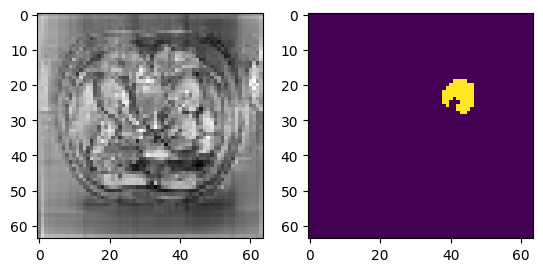

In [4]:
import matplotlib.pyplot as plt
test_downsampled_gt = cv2.resize(gts[22], dsize=(64, 64), interpolation=cv2.INTER_NEAREST)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(embeddings[22][128], cmap='gray')
ax[1].imshow(test_downsampled_gt)

In [17]:
train_embeddings = np.concatenate(train_embeddings)
train_gts = np.concatenate(train_gts)
print(train_embeddings.shape, train_gts.shape)

(6311936, 256) (6311936,)


In [28]:
# Create a linear regression model and fit it to the training data
model = LogisticRegression(max_iter=10000) 
model.fit(train_embeddings, train_gts)

LogisticRegression(max_iter=10000)

In [60]:
fname = training_pool[0]
imgs = np.load(fname)['imgs']
embeddings = np.load(fname)['img_embeddings']
gts = np.load(fname)['gts']
bboxes = []
pred = []
sam_random_40 = '/scratch/project/bollmann_lab/xincheng/segmentation/ALMRI/checkpoints/SAM_MRI_LeftKidney_random/seed2024/epochs100/SAM_vit_b_40_latest.pth'
sam_model = sam_model_registry['vit_b'](checkpoint=checkpoint).to(device)
sam_model.eval()
predictor = SamPredictor(sam_model)
for img, emb, gt in zip(imgs, embeddings, gts):    # (256, 64, 64) (256, 256)
    emb = emb.transpose(1,2,0).reshape(-1, 256)  # (64, 64, 256)
    y_pred = model.predict(emb)
    y_pred = y_pred.reshape((64,64))
    mask_pred_l = cv2.resize(y_pred, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_NEAREST)

    # Define the kernel for dilation
    kernel = np.ones((5, 5), np.uint8)

    eroded_mask = cv2.erode(mask_pred_l, kernel, iterations=3)
    dilate_mask = cv2.dilate(eroded_mask, kernel, iterations=5)

    # bbox 
    
    y_indices, x_indices = np.where(dilate_mask > 0)
    if np.all(dilate_mask == 0):
            bbox = np.array([0, 0, H, W])
    else:
        # print(y_indices, x_indices, np.unique(gt))
        x_min, x_max = np.min(x_indices), np.max(x_indices)
        y_min, y_max = np.min(y_indices), np.max(y_indices)
        H, W = dilate_mask.shape
        x_min = max(0, x_min - np.random.randint(0, 20))
        x_max = min(W, x_max + np.random.randint(0, 20))
        y_min = max(0, y_min - np.random.randint(0, 20))
        y_max = min(H, y_max + np.random.randint(0, 20))
        bbox = np.array([x_min, y_min, x_max, y_max])
    predictor.set_image(img)
    masks, _, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=bbox[None, :],
        multimask_output=False,
        )
    bboxes.append(bbox)
    pred.append(masks[0])


In [24]:
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='blue', facecolor=(0,0,0,0), lw=2)) 

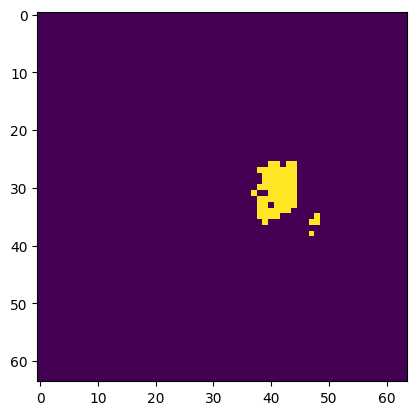

In [30]:
plt.imshow(y_pred)

Text(0.5, 1.0, 'GT')

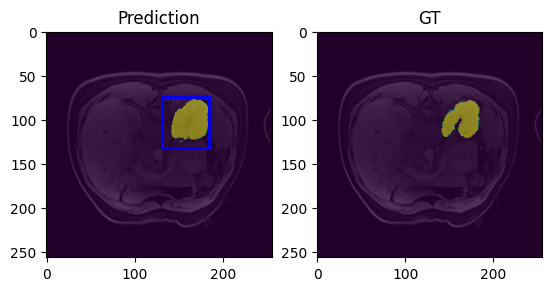

In [61]:
fig, ax = plt.subplots(1,2)
index = 22
ax[0].imshow(imgs[index])
ax[0].imshow(pred[index], alpha=0.5)
show_box(bboxes[index], ax[0])
ax[0].set_title('Prediction')

ax[1].imshow(imgs[index])
ax[1].imshow(gts[index], alpha=0.5)
ax[1].set_title('GT')

Text(0.5, 1.0, 'GT')

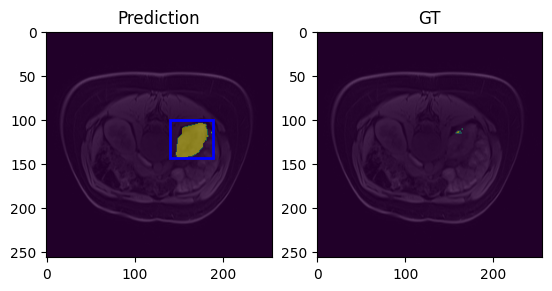

In [68]:
fig, ax = plt.subplots(1,2)
index = 1
ax[0].imshow(imgs[index])
ax[0].imshow(pred[index], alpha=0.5)
show_box(bboxes[index], ax[0])
ax[0].set_title('Prediction')

ax[1].imshow(imgs[index])
ax[1].imshow(gts[index], alpha=0.5)
ax[1].set_title('GT')

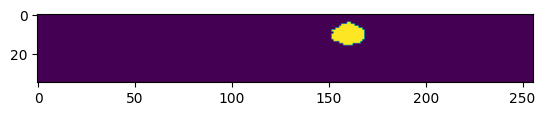

In [63]:
plt.imshow(gts[:,128,:])

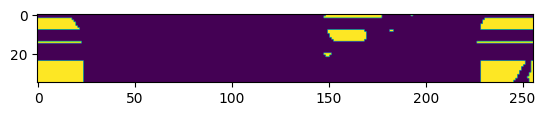

In [64]:
plt.imshow(np.array(pred)[:,128,:])

In [65]:
from metrics import compute_dice_coefficient
dice = compute_dice_coefficient(gts, np.array(pred))
print(dice)

0.04979965742253698
